# Key Efficiencies Comparison

This is the notebook to benchmark MD, SR and TPT, all over transmission distance. The asymptotic key rates are found as follows, where $m \geq 1$ is a free parameter for TPT and SR.

$$
K_\infty^\text{SR} = H(S_{1,\ldots,m}(X)) - \sum_{i \in m} h(e_\text{i, SR}) - \chi_{EB}
$$

$$
K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
$$

$$
K_\infty^\text{TPT} = p_\text{pass}(H(T(X)) - h(e_\text{TPT}) - \chi_{EB})
$$

Therefore, to plot these, we need to optimise each of the above key rates over $V_\text{mod}$ for a given $T(d) = 10^{-(\alpha d)/10}$ where $\alpha$ is the fibre loss coefficient, which we will say is 0.2 dB/km. For rigor, the optimisation problem becomes
$$
\max_{V_{\mathrm{mod}},\,\{\tau_i\}_{i=1}^M,\,\{g_{j,-},g_{j,+}\}_{j=-M}^M}
K_{\infty,\mathrm{TPT}}\Bigl(
    V_{\mathrm{mod}},\;
    \{\tau_{-M},\dots,\tau_{-1},0,\tau_{1},\dots,\tau_{M}\},\;
    \{g_{j,-},g_{j,+}\}_{j=-M}^M
    \;;\;T,\xi
\Bigr)
$$
where $g_{i,\pm} = 0 \;\; \forall i$ in the case of SR.

In [1]:
import numpy as np
import importlib
from tqdm import tqdm
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

from guard_band_postselection import GBSR
importlib.reload(GBSR)

print("Libraries imported.")

Libraries imported.


In [2]:
# Global variables and functions
distances = np.linspace(0, 100, 20)
fibre_loss_coeff = 0.2 # In dB/km

def T_from_d(d):
    # T(d) = 10^{-(\alpha d)/10}
    return np.power(10.0, -(fibre_loss_coeff * d) / 10.0)

## Asymptotic SR Key Rates (Efficiencies)

In [3]:
gbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = 0.011)

SR_key_rates = []
SR_error_rates = []
SR_v_mods = []
SR_p_passes = []
SR_leaked_informations = []
SR_Is = []

tau_arr = [-np.inf, 0.0, np.inf]
g_arr = [
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0]
]

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # First, optimise v_mod for this transmittance

    def v_mod_objective_function(v_mod):
        gbsr.__init__(1, v_mod, transmittance, 0.0, _lambda = 0.011)

        return -1.0 * gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)
    
    optimisation_return = minimize_scalar(v_mod_objective_function, bounds=(0.01, 10), method='bounded')

    SR_v_mods.append(optimisation_return.x)
    SR_key_rates.append(-optimisation_return.fun)

    # Set optimal gbsr
    gbsr.__init__(1, optimisation_return.x, transmittance, 0.0, _lambda = 0.011)

    # Evaluate other metrics
    p_pass = gbsr.evaluate_p_pass(tau_arr, g_arr)
    error_rate = gbsr.evaluate_error_rate(tau_arr, g_arr)
    leaked_information = gbsr._evaluate_leaked_information(error_rate)
    mutual_information = gbsr.I_AB

    SR_p_passes.append(p_pass)
    SR_leaked_informations.append(leaked_information)
    SR_error_rates.append(error_rate)
    SR_Is.append(mutual_information)

100%|██████████| 20/20 [01:51<00:00,  5.57s/it]


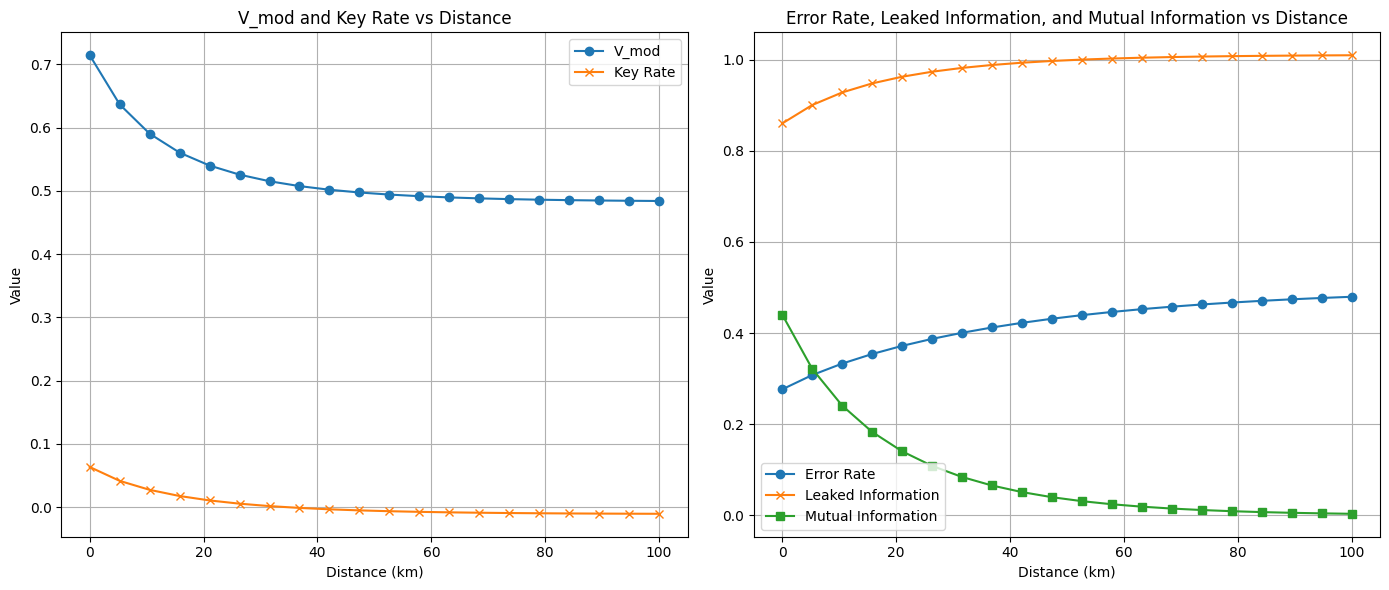

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: V_mod and key rate over distance
axes[0].plot(distances, SR_v_mods, marker='o', label='V_mod')
axes[0].plot(distances, SR_key_rates, marker='x', label='Key Rate')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Value')
axes[0].set_title('V_mod and Key Rate vs Distance')
axes[0].grid(True)
axes[0].legend()

# Right plot: Error rate, leaked information, and mutual information over distance
axes[1].plot(distances, SR_error_rates, marker='o', label='Error Rate')
axes[1].plot(distances, SR_leaked_informations, marker='x', label='Leaked Information')
axes[1].plot(distances, SR_Is, marker='s', label='Mutual Information')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Value')
axes[1].set_title('Error Rate, Leaked Information, and Mutual Information vs Distance')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

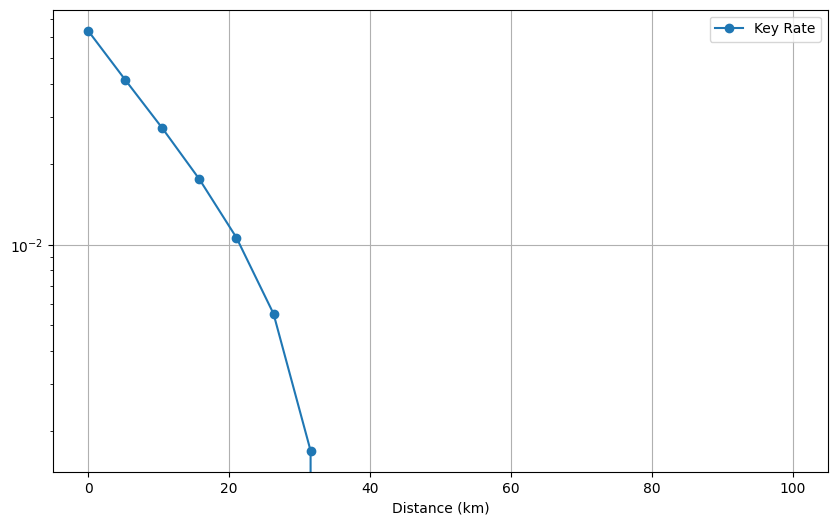

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(distances, SR_key_rates, label = "Key Rate", marker = 'o')
plt.yscale('log')
plt.xlabel('Distance (km)')
plt.grid(True)
plt.legend()
plt.show()

## Asymptotic TBT Key Efficiencies

In [6]:
TPT_key_rates = []
TPT_v_mods = [0.8] * len(distances)  # Constant V_mod
TPT_p_passes = []
TPT_leaked_informations = []
optimal_gs = [0.1] * len(distances)  # Constant g

for d in tqdm(distances):
    transmittance = T_from_d(d)
    v_mod = 0.8  # Constant V_mod
    g = 0.1  # Constant g

    # Initialize gbsr with constant V_mod and transmittance
    gbsr.__init__(1, v_mod, transmittance, 0.0, _lambda=0.011)

    # Evaluate key rate
    key_rate = gbsr.evaluate_key_rate_in_bits_per_pulse(
        tau_arr, [[0.0, 0.0], [g, g], [0.0, 0.0]]
    )
    TPT_key_rates.append(key_rate)

    # Extra metrics
    TPT_p_passes.append(
        gbsr.evaluate_p_pass(tau_arr, [[0.0, 0.0], [g, g], [0.0, 0.0]])
    )
    TPT_leaked_informations.append(
        gbsr._evaluate_leaked_information(
            gbsr.evaluate_error_rate(tau_arr, [[0.0, 0.0], [g, g], [0.0, 0.0]])
        )
    )


100%|██████████| 20/20 [00:16<00:00,  1.20it/s]


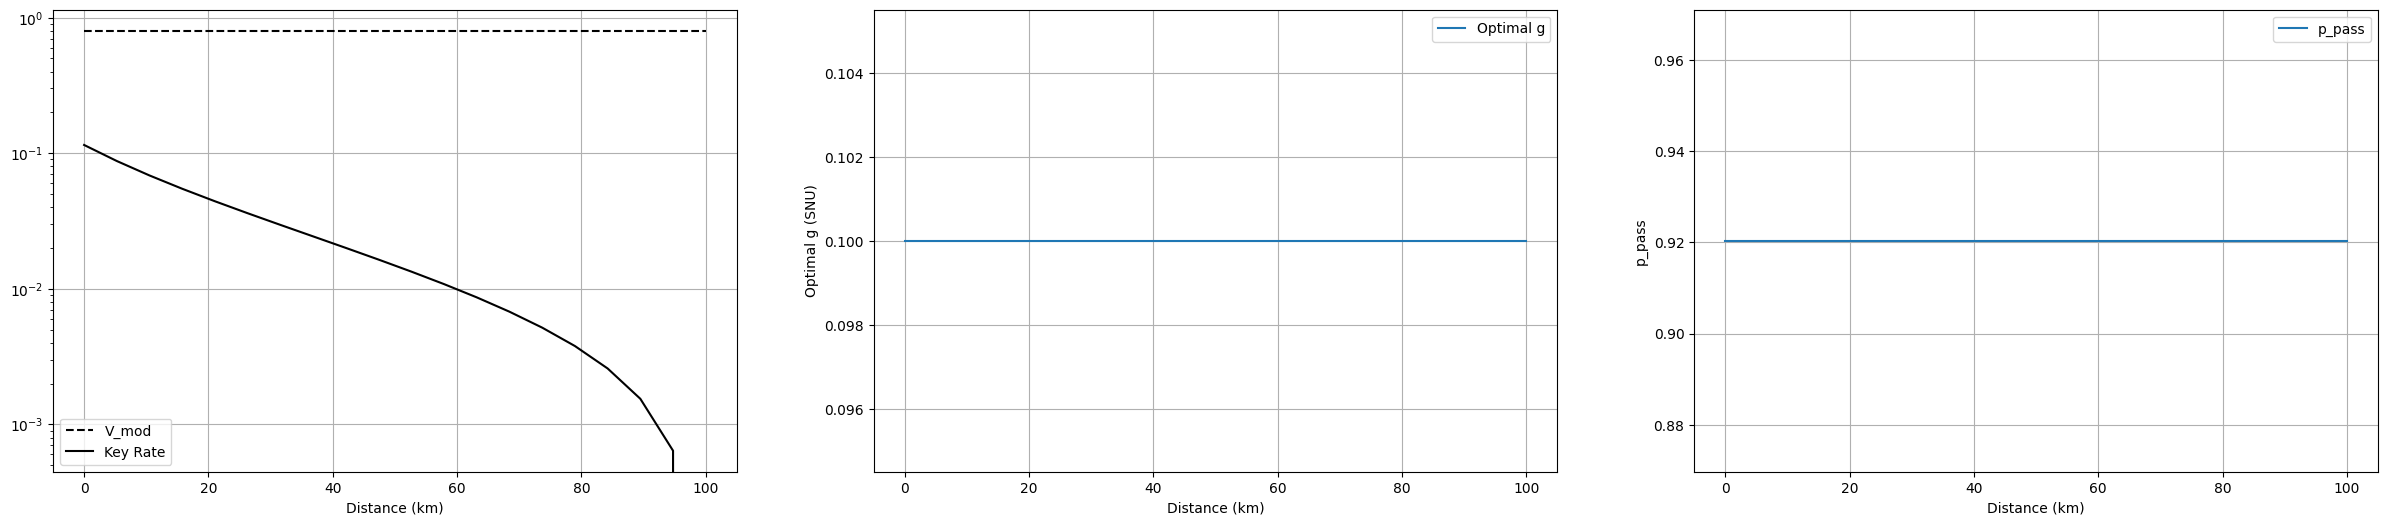

In [7]:
# Plot v_mods and key rates vs losses on one plot, g vs losses on another, and p_passes on the third, side by side
fig, axs = plt.subplots(1, 3, figsize=(30, 6))

# Plot V_mod and Key Rate
axs[0].plot(distances, TPT_v_mods, 'k--', label="V_mod")
axs[0].plot(distances, TPT_key_rates, 'k-', label="Key Rate")
axs[0].set_yscale('log')
axs[0].set_xlabel('Distance (km)')
axs[0].grid(True)
axs[0].legend()

# Plot Optimal g
axs[1].plot(distances, optimal_gs, label="Optimal g")
axs[1].set_xlabel('Distance (km)')
axs[1].set_ylabel('Optimal g (SNU)')
axs[1].grid(True)
axs[1].legend()

# Plot p_passes
axs[2].plot(distances, TPT_p_passes, label="p_pass")
axs[2].set_xlabel('Distance (km)')
axs[2].set_ylabel('p_pass')
axs[2].grid(True)
axs[2].legend()

plt.show()

## Asymptotic MD Key Efficiencies

In [8]:
gbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = 0.011)

MD_key_rates = []
MD_v_mods = []
MD_leaked_informations = []

# This has been checked against Jouguet-2011 table 1 for correctness
def C_biawgn(SNR):
    if SNR <= 0:
        return 0.0
    def integrand(z):
        pdf = norm.pdf(z)
        log2t = np.log1p(np.exp(-2*np.sqrt(SNR)*z - 2*SNR)) / np.log(2)
        return pdf * log2t
    res, _ = quad(integrand, -10, 10, epsabs=1e-10, epsrel=1e-10)
    return 1 - res

def MD_objective_function(variables, arguments):
    # K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
    (v_mod,) = variables
    transmittance = arguments

    # Only used to calculate Holevo information in this case.
    gbsr.__init__(1, v_mod, transmittance, 0.0, _lambda = 0.011)

    # Evaluate key rate terms
    bits_sent = 1.0
    leaked_information = (1 + 0.01) * (1.0 - C_biawgn(gbsr.SNR))
    holevo_information = gbsr.gaussian_attack_holevo_information

    # Key rate
    K = bits_sent - leaked_information - holevo_information

    return -1.0 * K

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Optimise v_mod
    optimisation_return = minimize(
        MD_objective_function,
        (0.5,),
        args=(transmittance,),
        bounds = [(0.01, 3.0)],
    )

    # Unpack optimisation return for plotting
    MD_v_mods.append(optimisation_return.x[0])
    MD_key_rates.append(-optimisation_return.fun)

    # Initialize gbsr with the optimal v_mod and transmittance
    gbsr.__init__(1, optimisation_return.x[0], transmittance, 0.0, _lambda = 0.011)
    
    # Append the leaked information using the SNR from the initialized gbsr
    MD_leaked_informations.append(C_biawgn(gbsr.SNR))


100%|██████████| 20/20 [00:05<00:00,  3.45it/s]


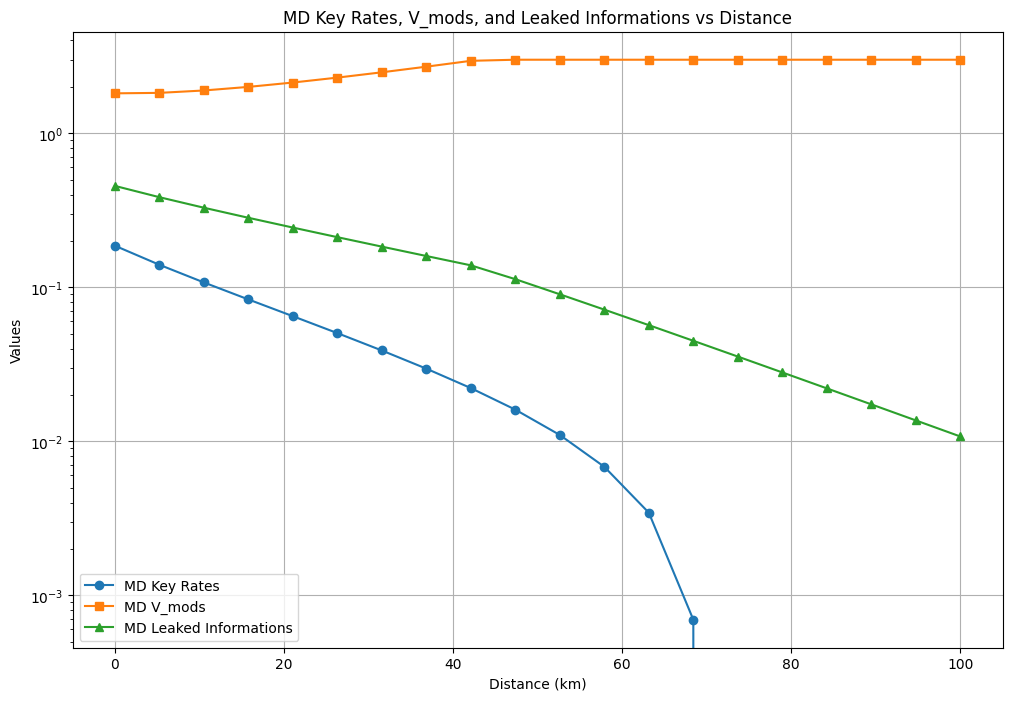

In [9]:
plt.figure(figsize=(12, 8))

# Plot MD_key_rates
plt.plot(distances, MD_key_rates, label="MD Key Rates", marker='o')

# Plot MD_v_mods
plt.plot(distances, MD_v_mods, label="MD V_mods", marker='s')

# Plot MD_leaked_informations
plt.plot(distances, MD_leaked_informations, label="MD Leaked Informations", marker='^')

# Add labels, legend, and grid
plt.xlabel('Distance (km)')
plt.ylabel('Values')
plt.title('MD Key Rates, V_mods, and Leaked Informations vs Distance')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.show()

## Asymptotic DW Key Efficiencies

In [10]:
DW_key_rates = []

for i, d in enumerate(distances):
    transmittance = T_from_d(d)

    gbsr = GBSR.GBSR(1, SR_v_mods[i], transmittance, 0.0)

    DW_key_rates.append(gbsr.devetak_winter)

## Final Asymptotic Key Efficiencies Plot

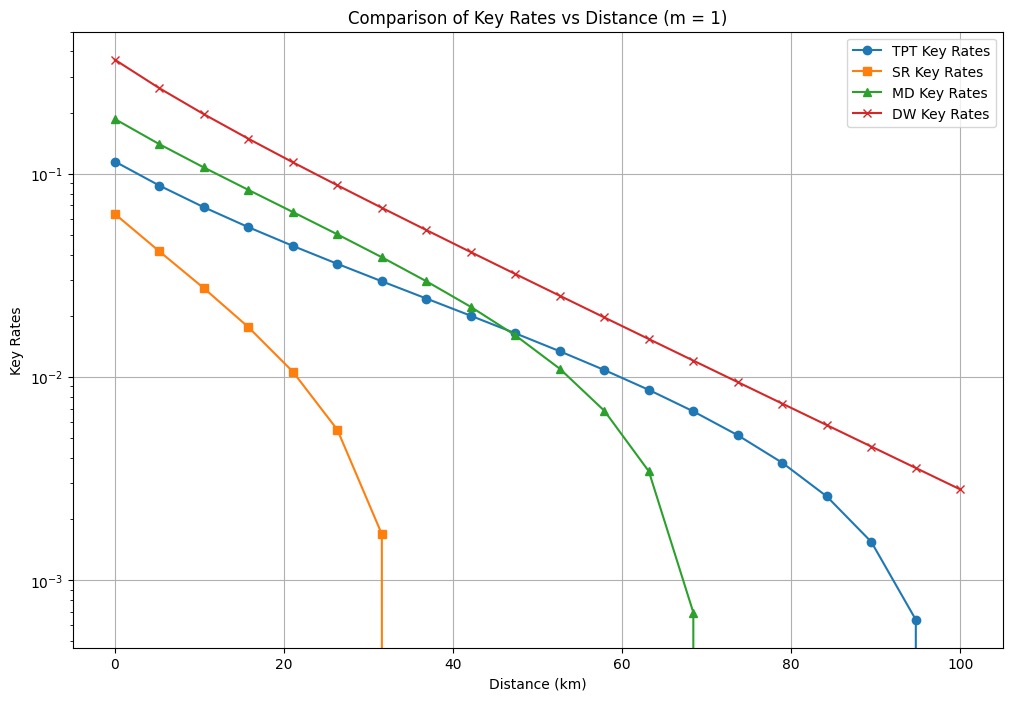

In [11]:
plt.figure(figsize=(12, 8))

# Plot TPT_key_rates
plt.plot(distances, TPT_key_rates, label="TPT Key Rates", marker='o')

# Plot SR_key_rates
plt.plot(distances, SR_key_rates, label="SR Key Rates", marker='s')

# Plot MD_key_rates
plt.plot(distances, MD_key_rates, label="MD Key Rates", marker='^')

# Plot DW_key_rates
plt.plot(distances, DW_key_rates, label="DW Key Rates", marker='x')

# Add labels, legend, and grid
plt.xlabel('Distance (km)')
plt.ylabel('Key Rates')
plt.title('Comparison of Key Rates vs Distance (m = 1)')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.show()